In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pl.read_csv("../data/raw/paysim.csv")
print(df.shape)
df.head()

(6362620, 11)


step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
i64,str,f64,str,f64,f64,str,f64,f64,i64,i64
1,"""PAYMENT""",9839.64,"""C1231006815""",170136.0,160296.36,"""M1979787155""",0.0,0.0,0,0
1,"""PAYMENT""",1864.28,"""C1666544295""",21249.0,19384.72,"""M2044282225""",0.0,0.0,0,0
1,"""TRANSFER""",181.0,"""C1305486145""",181.0,0.0,"""C553264065""",0.0,0.0,1,0
1,"""CASH_OUT""",181.0,"""C840083671""",181.0,0.0,"""C38997010""",21182.0,0.0,1,0
1,"""PAYMENT""",11668.14,"""C2048537720""",41554.0,29885.86,"""M1230701703""",0.0,0.0,0,0


In [3]:
(df.group_by("type")
   .agg(n=pl.len(), fraud=pl.col("isFraud").sum(), rate=pl.col("isFraud").mean())
   .sort("n", descending=True))

type,n,fraud,rate
str,u32,i64,f64
"""CASH_OUT""",2237500,4116,0.00184
"""PAYMENT""",2151495,0,0.0
"""CASH_IN""",1399284,0,0.0
"""TRANSFER""",532909,4097,0.007688
"""DEBIT""",41432,0,0.0


In [4]:
df = df.filter(pl.col("type").is_in(["TRANSFER", "CASH_OUT"]))
df.write_parquet("../data/processed/scoped.parquet")
print(df.shape, "fraud cases:", df["isFraud"].sum(), "fraud rate:", round(df["isFraud"].mean(), 5))

(2770409, 11) fraud cases: 8213 fraud rate: 0.00296


**Finding 1:** Fraud only occurs in TRANSFER and CASH_OUT payments, so I limited the analysis to these (~2.77M rows). Fraud is ~0.3% of these payments, a heavily imbalanced problem.

In [5]:
print("Sender accounts, unique share:  ", round(df["nameOrig"].n_unique() / len(df), 4))
print("Receiver accounts, unique share:", round(df["nameDest"].n_unique() / len(df), 4))

Sender accounts, unique share:   0.9994
Receiver accounts, unique share: 0.1839


In [6]:
from scipy.stats import mannwhitneyu

fraud_amt = df.filter(pl.col("isFraud") == 1)["amount"].to_numpy()
legit_amt = df.filter(pl.col("isFraud") == 0)["amount"].to_numpy()

u, p = mannwhitneyu(fraud_amt, legit_amt, alternative="two-sided")
r = 2 * u / (len(fraud_amt) * len(legit_amt)) - 1

print(f"p-value: {p:.2e}")
print(f"Effect size (rank-biserial r): {r:.3f}")
print("Median fraud amount:", round(np.median(fraud_amt)))
print("Median legit amount:", round(np.median(legit_amt)))

p-value: 0.00e+00
Effect size (rank-biserial r): 0.367
Median fraud amount: 441423
Median legit amount: 171034


chi2=263619, p=0.00e+00, Cramér's V=0.308


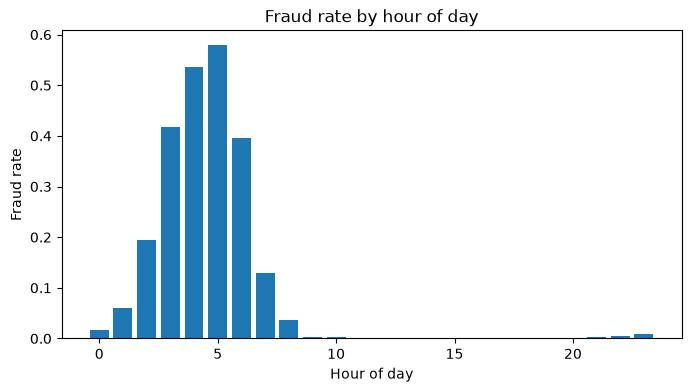

In [7]:
from scipy.stats import chi2_contingency

hourly = (df.with_columns(hour=pl.col("step") % 24)
            .group_by("hour")
            .agg(fraud=pl.col("isFraud").sum(),
                 legit=(1 - pl.col("isFraud")).sum())
            .sort("hour"))

table = hourly.select(["fraud", "legit"]).to_numpy()
chi2, p, dof, _ = chi2_contingency(table)
cramers_v = np.sqrt(chi2 / table.sum())
print(f"chi2={chi2:.0f}, p={p:.2e}, Cramér's V={cramers_v:.3f}")

h = hourly.to_pandas()
plt.figure(figsize=(8, 4))
plt.bar(h["hour"], h["fraud"] / (h["fraud"] + h["legit"]))
plt.title("Fraud rate by hour of day")
plt.xlabel("Hour of day"); plt.ylabel("Fraud rate")
plt.savefig("../reports/figures/fraud_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
check = df.with_columns(
    dest_zero_both=((pl.col("oldbalanceDest") == 0) &
                    (pl.col("newbalanceDest") == 0) &
                    (pl.col("amount") > 0)),
    orig_err=(pl.col("newbalanceOrig") + pl.col("amount") - pl.col("oldbalanceOrg")).abs() > 1,
)
check.group_by("isFraud").agg(
    pl.col("dest_zero_both").mean().alias("share_dest_balance_stays_0"),
    pl.col("orig_err").mean().alias("share_sender_balance_doesnt_add_up"),
)

isFraud,share_dest_balance_stays_0,share_sender_balance_doesnt_add_up
i64,f64,f64
1,0.495556,0.005479
0,0.000618,0.900952


In [9]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

leaky_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
safe_cols  = ["amount", "oldbalanceOrg"]

pdf = df.select(leaky_cols + ["isFraud"]).to_pandas()
for name, cols in [("LEAKY", leaky_cols), ("REALISTIC", safe_cols)]:
    Xtr, Xte, ytr, yte = train_test_split(pdf[cols], pdf["isFraud"], test_size=0.3,
                                          stratify=pdf["isFraud"], random_state=0)
    m = lgb.LGBMClassifier(n_estimators=200, verbose=-1).fit(Xtr, ytr)
    print(name, "PR-AUC:", round(average_precision_score(yte, m.predict_proba(Xte)[:, 1]), 3))

LEAKY PR-AUC: 0.577
REALISTIC PR-AUC: 0.266


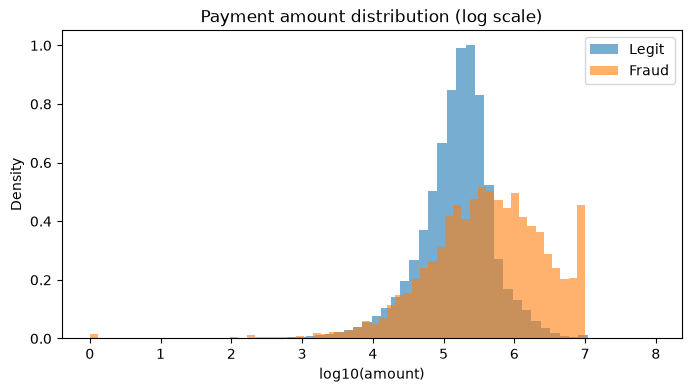

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(np.log10(legit_amt + 1), bins=60, alpha=0.6, density=True, label="Legit")
plt.hist(np.log10(fraud_amt + 1), bins=60, alpha=0.6, density=True, label="Fraud")
plt.title("Payment amount distribution (log scale)")
plt.xlabel("log10(amount)"); plt.ylabel("Density"); plt.legend()
plt.savefig("../reports/figures/amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

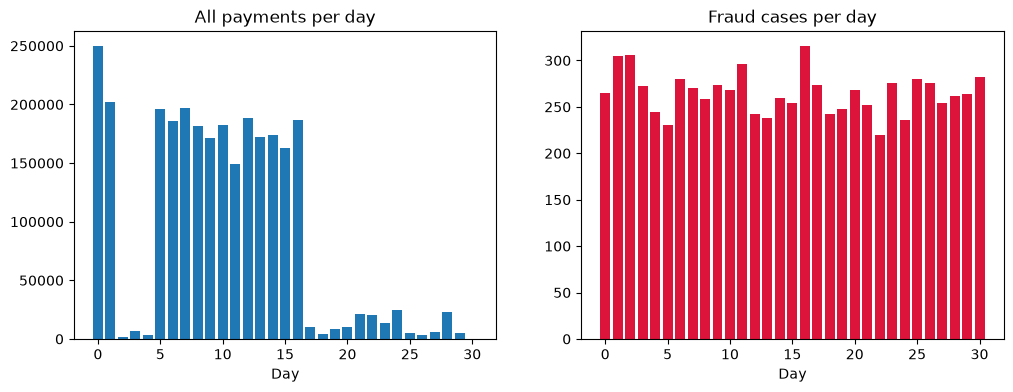

In [11]:
daily = (df.with_columns(day=pl.col("step") // 24)
           .group_by("day").agg(fraud=pl.col("isFraud").sum(), total=pl.len())
           .sort("day").to_pandas())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(daily["day"], daily["total"]); ax[0].set_title("All payments per day")
ax[1].bar(daily["day"], daily["fraud"], color="crimson"); ax[1].set_title("Fraud cases per day")
for a in ax: a.set_xlabel("Day")
plt.savefig("../reports/figures/volume_per_day.png", dpi=150, bbox_inches="tight")
plt.show()

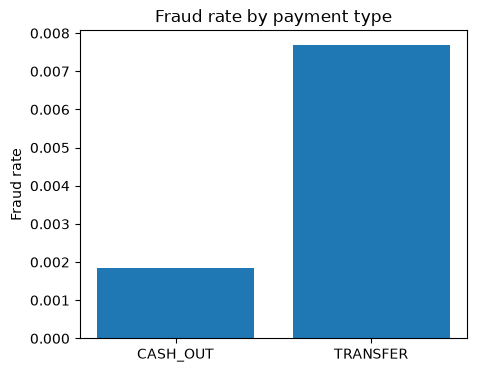

In [12]:
bt = (df.group_by("type").agg(rate=pl.col("isFraud").mean()).to_pandas())
plt.figure(figsize=(5, 4))
plt.bar(bt["type"], bt["rate"]); plt.title("Fraud rate by payment type"); plt.ylabel("Fraud rate")
plt.savefig("../reports/figures/fraud_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

## Key takeaways
1. Fraud only happens in TRANSFER and CASH_OUT; ~0.3% of these are fraud (heavily imbalanced).
2. Fraud amounts are larger (effect size r = ...), and fraud is proportionally higher at night.
3. Sender accounts don't repeat; receiver accounts do, so behaviour features will focus on receivers.
4. Post-payment balance columns leak the label. I excluded them to keep the model realistic.
5. Normal payment volume drops in later days while fraud stays steady, which affects how I split the data.